# Kvantitativna karakterizacija varijabilnosti i akrecionih procesa u X-ray binarnom sistemu uz uporednu statističku analizu varijabilnosti u srodnim sistemima

U ovom projektu analiziraju se vremenske i statističke karakteristike varijabilnosti X-ray binarnih sistema sa neutronskim zvezdama, sa posebnim fokusom na ulogu akrecionih procesa u formiranju promena fluksa.

Posmatrana varijabilnost predstavlja direktan trag fizičkih procesa u unutrašnjim regionima sistema, prvenstveno u akrecionom disku i njegovoj interakciji sa kompaktnim objektom. Zbog toga analiza promena fluksa omogućava indirektno proučavanje regiona koji nisu prostorno razlučivi.

Cilj rada je kvantitativna karakterizacija:
- intenziteta varijabilnosti,
- raspodele fluksa,
- vremenske organizacije signala,
- dominantnih vremenskih skala,
- i mikrovarijabilnosti sistema.

## Izbor sistema 

Kao glavni sistem analize izabran je **Sco X-1**, jedan od najpoznatijih i najaktivnijih X-ray binarnih sistema sa neutronskom zvezdom.

Radi fizički smislenije interpretacije rezultata uključena su još dva referentna sistema:
- **Her X-1**
- **Cyg X-2**

Poređenjem ova tri sistema moguće je razlikovati:
- uticaj akrecionih procesa,
- geometrijske efekte,
- i različite režime vremenske organizacije varijabilnosti.

## Prvi deo projekta — fotometrijska karakterizacija varijabilnosti

Prvi deo projekta  je usmeren na kvantitativnu analizu varijabilnosti sistema Sco X-1 korišćenjem dugoročnih fotometrijskih podataka.

Kroz:
- čišćenje i filtriranje svetlosnih krivih,
- osnovnu statističku analizu,
- analizu raspodele fluksa,
- vremensku analizu,
- mikrovarijabilnost,
- i uporednu analizu sa sistemima Her X-1 i Cyg X-2,

izvršena je detaljna karakterizacija promenljivosti sistema i određene su dominantne osobine njegove varijabilnosti.

Dobijeni rezultati pokazali su da se sistemi razlikuju ne samo po intenzitetu promena, već i po vremenskoj organizaciji signala, strukturi raspodele fluksa i ulozi brzih fluktuacija u ukupnoj varijabilnosti.

Na osnovu ovih rezultata formirana je stabilna osnova za prelazak na naredni deo projekta, koji je usmeren na fizičku interpretaciju dobijene varijabilnosti.

## Prikupljanje podataka

Fotometrijski podaci preuzeti su iz baze ASAS-SN.

Za sve sisteme korišćen je isti fotometrijski filter (`g` filter), kako bi podaci bili međusobno uporedivi.

Analizirane su dugotrajne svetlosne krive sa nepravilnim vremenskim uzorkovanjem.


**** Izbor filtera ****

Sco X-1
Broj tačaka posle izbora filtera: 917
JD opseg: 2458140.0238087 - 2460833.8702808

Her X-1
Broj tačaka posle izbora filtera: 646
JD opseg: 2458028.5891055 - 2460693.9876367

Cyg X-2
Broj tačaka posle izbora filtera: 731
JD opseg: 2458220.9751496 - 2460670.6027426


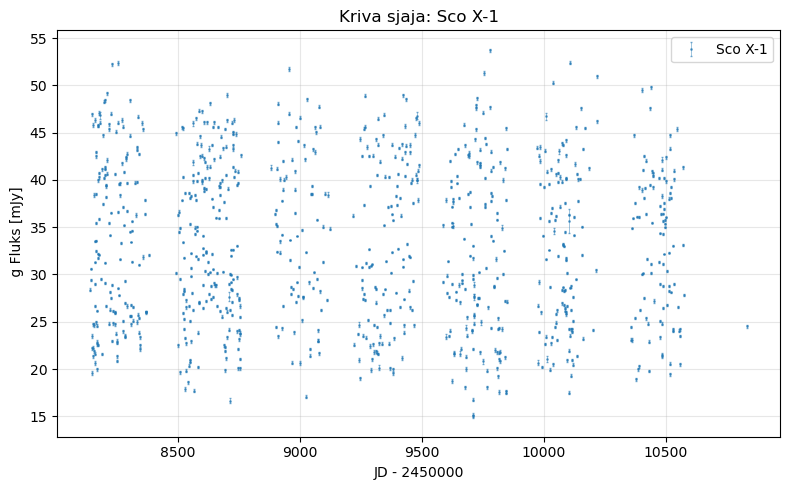

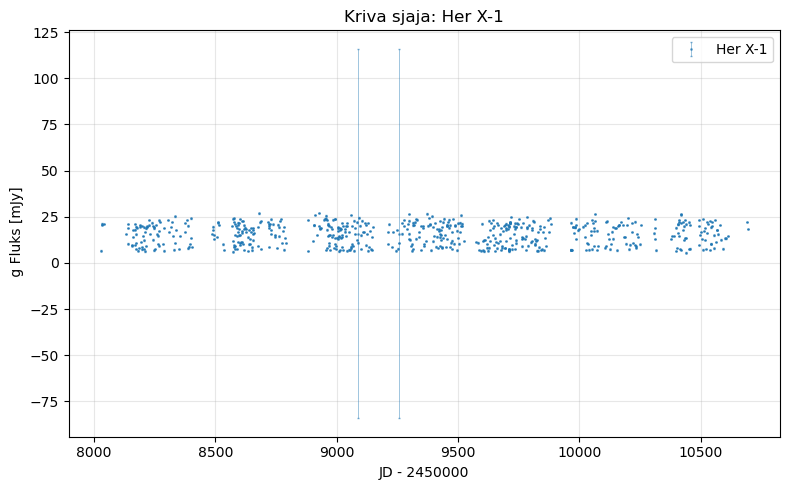

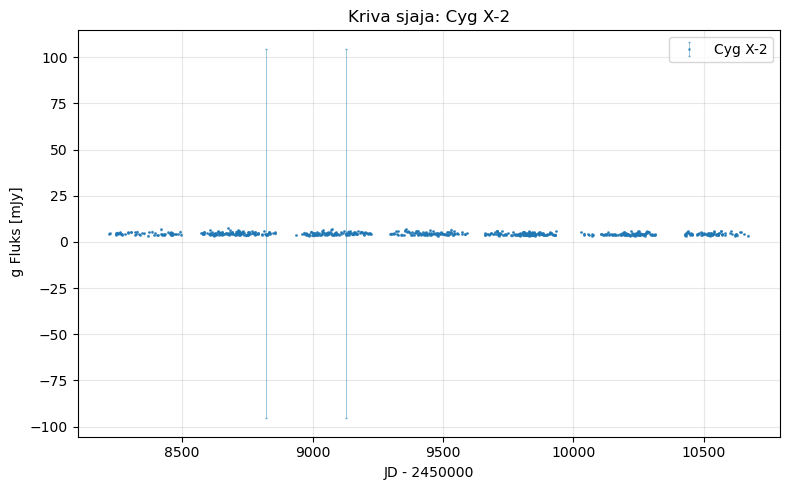

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
#  UČITAVANJE PODATAKA I IZBOR FOTOMETRIJSKOG FILTERA
# ============================================================

print("\n**** Izbor filtera ****")
def ucitaj_krivu(fajl, ime_objekta, filter_kanal="g"):
    df = pd.read_csv(fajl, comment="#")  # učitavanje CSV fajla; redovi koji počinju sa # se preskaču

    df = df.replace([np.inf, -np.inf], np.nan)  # beskonačne vrednosti se pretvaraju u NaN

    df = df[df["Filter"] == filter_kanal]  # koristi se samo jedan filter zbog konzistentnog poređenja

    df = df.dropna(subset=["JD", "Flux", "Flux Error", "Mag", "Mag Error"])  # uklanjanje nepotpunih merenja

    df = df.sort_values("JD").reset_index(drop=True)  # sortiranje po vremenu

    vreme = df["JD"]  # vreme posmatranja u Julijanskim danima
    fluks = df["Flux"]  # instrumentalni fluks
    greska_fluksa = df["Flux Error"]  # greška merenja fluksa
    
    print(f"\n{ime_objekta}")
    print("Broj tačaka posle izbora filtera:", len(vreme))
    print("JD opseg:", np.min(vreme), "-", np.max(vreme))

    return df, vreme, fluks, greska_fluksa


# ============================================================
#  UČITAVANJE KRIVIH SJAJA ZA SVA TRI SISTEMA
# ============================================================

df_sco, vreme_sco, fluks_sco, greska_sco = ucitaj_krivu("sco.csv", "Sco X-1")
df_her, vreme_her, fluks_her, greska_her = ucitaj_krivu("her.csv", "Her X-1")
df_cyg, vreme_cyg, fluks_cyg, greska_cyg = ucitaj_krivu("cyg.csv", "Cyg X-2")


# ============================================================
#  FUNKCIJA ZA PRIKAZ KRIVE SJAJA U FLUKSU
# ============================================================

def nacrtaj_fluks(vreme, fluks, greska, ime_objekta):
    jd0 = 2450000
    plt.figure(figsize=(8, 5))

    plt.errorbar(
        vreme - jd0, fluks,
        yerr=greska,             # greške se ne izbacuju; prikazuju se kao errorbar
        fmt=".",                 # tačke
        markersize=2,            # veličina tačke
        elinewidth=0.5,          # širina linije greške
        capsize=1,               # veličina tačke na liniji greške
        alpha=0.6,               # transparentnost
        label=ime_objekta
    )
    plt.xlabel(f"JD - {jd0}")    # JD 2450000.0=1995−10−09 12:00 UT
    plt.ylabel(r" g Fluks [mJy]")
    plt.title(f"Kriva sjaja: {ime_objekta}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ============================================================
#  FUNKCIJA ZA PRIKAZ KRIVE SJAJA U MAGNITUDAMA
# ============================================================

def nacrtaj_magnitudu(df, ime_objekta):
    jd0 = 2450000
    vreme = df["JD"]
    magnituda = df["Mag"]
    greska_magnitude = df["Mag Error"]

    plt.figure(figsize=(8, 5))

    plt.errorbar(
        vreme - jd0, magnituda,
        yerr=greska_magnitude,
        fmt=".",
        markersize=2,
        elinewidth=0.5,
        capsize=1,
        alpha=0.6,
        label=ime_objekta
    )

    plt.gca().invert_yaxis()  # veća magnitudama manji sjaj
    plt.xlabel(f"JD - {jd0}")
    plt.ylabel(r"$g$ magnituda")
    plt.title(f"Kriva sjaja (magnituda): {ime_objekta}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ============================================================
#  POČETNI VIZUELNI PREGLED SIROVIH KRIVIH SJAJA
# ============================================================

nacrtaj_fluks(vreme_sco, fluks_sco, greska_sco, "Sco X-1")
nacrtaj_fluks(vreme_her, fluks_her, greska_her, "Her X-1")
nacrtaj_fluks(vreme_cyg, fluks_cyg, greska_cyg, "Cyg X-2")

# Po potrebi se mogu prikazati i magnitude:
#nacrtaj_magnitudu(df_sco, "Sco X-1")
#nacrtaj_magnitudu(df_her, "HZ Her")
#nacrtaj_magnitudu(df_cyg, "Cyg X-2")

## Uklanjanje ekstremnih i nepouzdanih vrednosti

Pre statističke analize izvršeno je čišćenje svetlosnih krivih.

Primenjena je robusna sigma-clipping metoda zasnovana na medijani i MAD parametru.

#### Median Absolute Deviation (MAD)

$$
\mathrm{MAD} =
\mathrm{median}
\left(
|F_i-\tilde{F}|
\right)
$$
gde je:
- $F_i$ fluks,
- $\tilde{F}$ medijana fluksa.

#### Robusna procena standardne devijacije

$$
\sigma_{\mathrm{rob}}
=
1.4826 \cdot \mathrm{MAD}
$$

#### Sigma-clipping uslov

Zadržane su samo vrednosti koje zadovoljavaju:

$$
\tilde{F}
-
5\sigma_{\mathrm{rob}}
<
F_i
<
\tilde{F}
+
5\sigma_{\mathrm{rob}}
$$

Dodatno su uklonjena merenja sa najvećim fotometrijskim greškama korišćenjem 95. percentila raspodele grešaka.

Na ovaj način smanjen je uticaj:
- outliera,
- šuma,
- i nepouzdanih merenja.

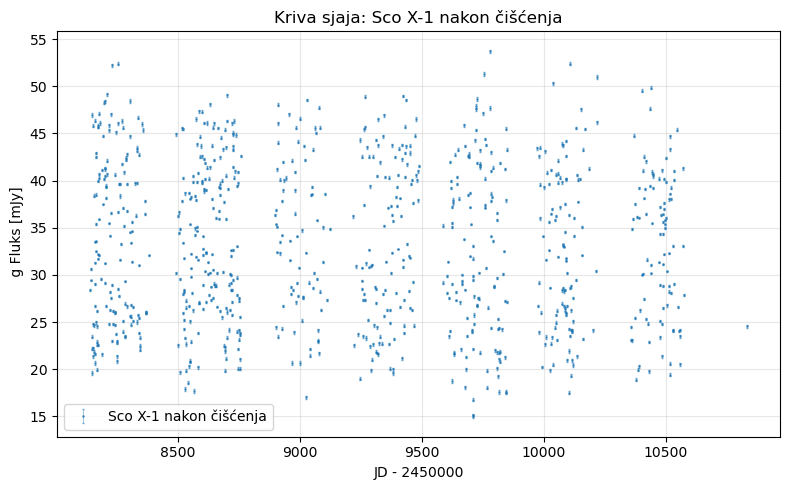

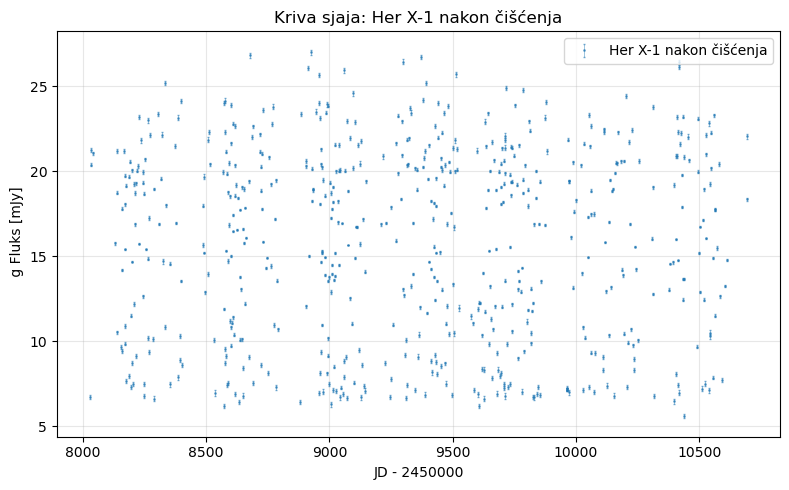

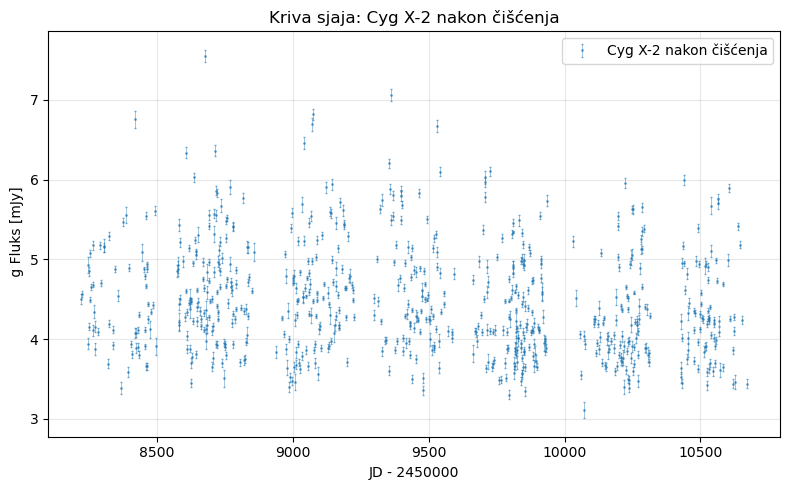


**** Broj tačaka pre i posle čišćenja ****

Sco X-1: 917 -> 871
Her X-1: 646 -> 613
Cyg X-2: 731 -> 694


In [6]:
# ============================================================
#  ROBUSNI SIGMA-CLIPPING OUTLIERA POMOĆU MEDIJANE I MAD
# ============================================================

def sigma_clipping_mad(vreme, fluks, greska, prag=5):
    medijana = np.median(fluks)  # medijana je stabilnija od srednje vrednosti kod outliera

    mad = np.median(np.abs(fluks - medijana))  # MAD = median absolute deviation

    sigma_rob = 1.4826 * mad  # pretvaranje MAD u procenu standardne devijacije

    donja_granica = medijana - prag * sigma_rob  # donja granica prihvatljivog fluksa
    gornja_granica = medijana + prag * sigma_rob  # gornja granica prihvatljivog fluksa

    maska = (fluks > donja_granica) & (fluks < gornja_granica)  # zadržavaju se samo normalne tačke

    return vreme[maska], fluks[maska], greska[maska]


vreme_sco_cisto1, fluks_sco_cist1, greska_sco_cista1 = sigma_clipping_mad(
    vreme_sco, fluks_sco, greska_sco
)

vreme_her_cisto1, fluks_her_cist1, greska_her_cista1 = sigma_clipping_mad(
    vreme_her, fluks_her, greska_her
)

vreme_cyg_cisto1, fluks_cyg_cist1, greska_cyg_cista1 = sigma_clipping_mad(
    vreme_cyg, fluks_cyg, greska_cyg
)


# ============================================================
#  UKLANJANJE TAČAKA SA PREVELIKOM FOTOMETRIJSKOM GREŠKOM
# ============================================================

def ukloni_velike_greske(vreme, fluks, greska, procenat=95):
    granica_greske = np.percentile(greska, procenat)  # uzima se 95. percentil greške

    maska = greska < granica_greske  # uklanja se najgorih 5% merenja po grešci

    return vreme[maska], fluks[maska], greska[maska]


vreme_sco_cisto2, fluks_sco_cist2, greska_sco_cista2 = ukloni_velike_greske(
    vreme_sco_cisto1, fluks_sco_cist1, greska_sco_cista1
)

vreme_her_cisto2, fluks_her_cist2, greska_her_cista2 = ukloni_velike_greske(
    vreme_her_cisto1, fluks_her_cist1, greska_her_cista1
)

vreme_cyg_cisto2, fluks_cyg_cist2, greska_cyg_cista2 = ukloni_velike_greske(
    vreme_cyg_cisto1, fluks_cyg_cist1, greska_cyg_cista1
)





# ============================================================
#  VIZUELNA PROVERA FILTRIRANIH KRIVIH SJAJA
# ============================================================

nacrtaj_fluks(vreme_sco_cisto2, fluks_sco_cist2, greska_sco_cista2, "Sco X-1 nakon čišćenja")
nacrtaj_fluks(vreme_her_cisto2, fluks_her_cist2, greska_her_cista2, "Her X-1 nakon čišćenja")
nacrtaj_fluks(vreme_cyg_cisto2, fluks_cyg_cist2, greska_cyg_cista2, "Cyg X-2 nakon čišćenja")


# ============================================================
#  PROVERA BROJA TAČAKA PRE I POSLE FILTRIRANJA
# ============================================================

print("\n**** Broj tačaka pre i posle čišćenja ****\n")

print("Sco X-1:", len(fluks_sco), "->", len(fluks_sco_cist2))
print("Her X-1:", len(fluks_her), "->", len(fluks_her_cist2))
print("Cyg X-2:", len(fluks_cyg), "->", len(fluks_cyg_cist2))



### Komentar rezultata

Nakon sigma-clipping postupka i filtriranja po fotometrijskim greškama uklonjen je približno isti procenat tačaka kod sva tri sistema: oko 5%.

Kod Sco X-1 broj tačaka smanjen je sa 917 na 871, kod Her X-1 sa 646 na 613, a kod Cyg X-2 sa 731 na 694. Sličan procenat uklonjenih merenja pokazuje da postupak čišćenja nije neravnomerno uticao na jedan sistem u odnosu na druge.

Time su uklonjene ekstremne i nepouzdane vrednosti, ali je očuvana osnovna struktura svetlosnih krivih. Očišćeni podaci mogu se koristiti za dalju statističku i vremensku analizu.

## Osnovna statistika varijabilnosti

Nakon filtriranja podataka izračunati su osnovni statistički parametri svetlosnih krivih.

#### Srednja vrednost fluksa

$$
\langle F \rangle
=
\frac{1}{N}
\sum_{i=1}^{N}F_i
$$

#### Standardna devijacija

$$
\sigma
=
\sqrt{
\frac{1}{N}
\sum_{i=1}^{N}
(F_i-\langle F\rangle)^2
}
$$

#### RMS vrednost

$$
\mathrm{RMS}
=
\sqrt{
\frac{1}{N}
\sum_{i=1}^{N}
F_i^2
}
$$

#### Amplituda

$$
A
=
F_{\max}-F_{\min}
$$

#### Robusna amplituda

$$
A_{95-5}
=
P_{95}(F)-P_{5}(F)
$$

Robusna amplituda daje reprezentativniju procenu tipičnog raspona promena jer smanjuje uticaj ekstremnih vrednosti.

#### Frakcijska varijabilnost

$$
F_{\mathrm{var}}
=
\frac{
\sqrt{
\sigma^2-
\langle \sigma_F^2\rangle
}
}
{
\langle F\rangle
}
$$

gde je:
- $\sigma$ standardna devijacija,
- $\langle \sigma_F^2\rangle$ srednja kvadratna vrednost fotometrijske greške.

#### Skewness

$$
S
=
\frac{1}{N}
\sum_{i=1}^{N}
\left(
\frac{F_i-\langle F\rangle}{\sigma}
\right)^3
$$

#### Kurtosis

$$
K
=
\frac{1}{N}
\sum_{i=1}^{N}
\left(
\frac{F_i-\langle F\rangle}{\sigma}
\right)^4
-3
$$

Skewness opisuje asimetriju raspodele fluksa, dok kurtosis opisuje izraženost repova raspodele i prisustvo ekstremnih događaja.

In [8]:
# ============================================================
#  OSNOVNA STATISTIKA VARIJABILNOSTI 
# ============================================================

from scipy.stats import skew, kurtosis
print("\n**** Osnovna statistika ****")
def osnovna_statistika(vreme, fluks, greska, ime_objekta):
    # srednja vrednost fluksa
    srednja = np.mean(fluks)
    
    # standardna devijacija
    std = np.std(fluks)
    
    # RMS (root mean square)
    rms = np.sqrt(np.mean(fluks**2))
    
    # amplituda (raspon)
    amplituda = np.max(fluks) - np.min(fluks)
    
    # ========================================================
    # ROBUSNA AMPLITUDA (P95 - P5)
    # ========================================================
    p95 = np.percentile(fluks, 95)
    p5 = np.percentile(fluks, 5)
    amplituda_rob = p95 - p5
    
    # ========================================================
    # OBLIK RASPODELE
    # ========================================================
    skewness = skew(fluks)
    kurt = kurtosis(fluks)  # Fisher (0 = normalna raspodela)
    
    # srednja kvadratna greška
    srednja_greska2 = np.mean(greska**2)
    
    # Fvar (frakcijska varijabilnost)
    if std**2 > srednja_greska2:
        fvar = np.sqrt(std**2 - srednja_greska2) / srednja
    else:
        fvar = np.nan
    
    # ========================================================
    # ISPIS
    # ========================================================
    print(f"\n{ime_objekta}")
    print(f"Srednja vrednost: {srednja:.3f}")
    print(f"Standardna devijacija: {std:.3f}")
    print(f"RMS: {rms:.3f}")
    print(f"Amplituda: {amplituda:.3f}")
    print(f"Robusna amplituda (P95-P5): {amplituda_rob:.3f}")
    print(f"Fvar: {fvar:.3f}")
    print(f"Skewness: {skewness:.3f}")
    print(f"Kurtosis: {kurt:.3f}")

    return {
        "sistem": ime_objekta,
        "srednja": srednja,
        "std": std,
        "rms": rms,
        "amplituda": amplituda,
        "amplituda_rob": amplituda_rob,
        "fvar": fvar,
        "skewness": skewness,
        "kurtosis": kurt
    }


# ============================================================
# PRIMENA NA FILTRIRANE PODATKE
# ============================================================

stat_sco = osnovna_statistika(
    vreme_sco_cisto2, fluks_sco_cist2, greska_sco_cista2, "Sco X-1"
)

stat_her = osnovna_statistika(
    vreme_her_cisto2, fluks_her_cist2, greska_her_cista2, "Her X-1"
)

stat_cyg = osnovna_statistika(
    vreme_cyg_cisto2, fluks_cyg_cist2, greska_cyg_cista2, "Cyg X-2"
)


**** Osnovna statistika ****

Sco X-1
Srednja vrednost: 33.145
Standardna devijacija: 8.454
RMS: 34.206
Amplituda: 38.715
Robusna amplituda (P95-P5): 25.653
Fvar: 0.255
Skewness: 0.099
Kurtosis: -1.102

Her X-1
Srednja vrednost: 15.686
Standardna devijacija: 5.592
RMS: 16.653
Amplituda: 21.398
Robusna amplituda (P95-P5): 16.701
Fvar: 0.356
Skewness: -0.148
Kurtosis: -1.227

Cyg X-2
Srednja vrednost: 4.471
Standardna devijacija: 0.674
RMS: 4.522
Amplituda: 4.437
Robusna amplituda (P95-P5): 2.100
Fvar: 0.150
Skewness: 0.844
Kurtosis: 0.778


### Komentar rezultata

Rezultati osnovne statistike pokazuju da Sco X-1 ima najveće apsolutne promene fluksa. To se vidi iz najveće standardne devijacije, najveće klasične amplitude i najveće robusne amplitude.

Međutim, frakcijska varijabilnost pokazuje drugačiju sliku. Her X-1 ima najveću relativnu varijabilnost, dok se Sco X-1 nalazi između Her X-1 i stabilnijeg sistema Cyg X-2. To znači da Sco X-1 ima najveće apsolutne promene, ali ne i najveću promenljivost u odnosu na sopstveni srednji fluks.

Robusna amplituda je kod sva tri sistema manja od klasične amplitude, što pokazuje da pojedinačne ekstremne vrednosti povećavaju ukupni raspon fluksa. Ipak, redosled sistema ostaje isti: Sco X-1 ima najveći tipičan raspon promena, Her X-1 srednji, a Cyg X-2 najmanji.

Skewness i kurtosis dopunjuju sliku raspodele. Sco X-1 i Her X-1 imaju približno simetrične raspodele i negativan kurtosis, što ukazuje na šire i ravnije raspodele bez dominantnih ekstremnih repova. Cyg X-2 ima pozitivniji skewness i kurtosis, što ukazuje na asimetriju ka većim vrednostima fluksa i ređa izraženija odstupanja.

## Analiza raspodele fluksa

Radi ispitivanja strukture varijabilnosti analizirani su histogrami fluksa i KDE aproksimacije raspodele.

#### Histogram

Histogram predstavlja diskretnu aproksimaciju raspodele verovatnoće:

$$
p(F)
\approx
\frac{N_j}{N\Delta F}
$$

#### Kernel Density Estimation (KDE)

$$
\hat{p}(F)
=
\frac{1}{Nh}
\sum_{i=1}^{N}
K
\left(
\frac{F-F_i}{h}
\right)
$$

Analiza raspodele omogućava identifikaciju:
- dominantnih režima emisije,
- asimetrije raspodele,
- višestrukih stanja sistema,
- i stabilnosti signala.

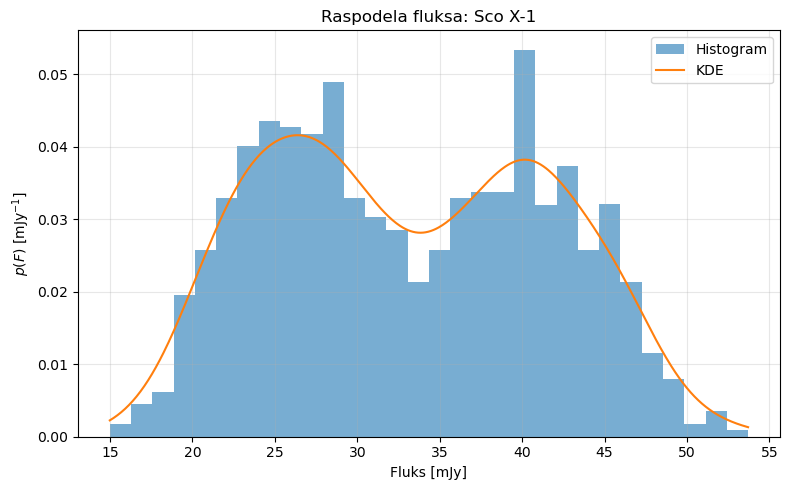

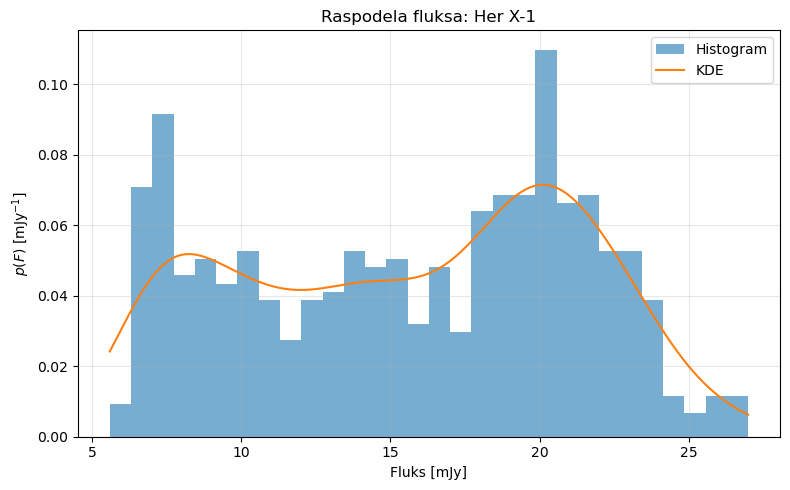

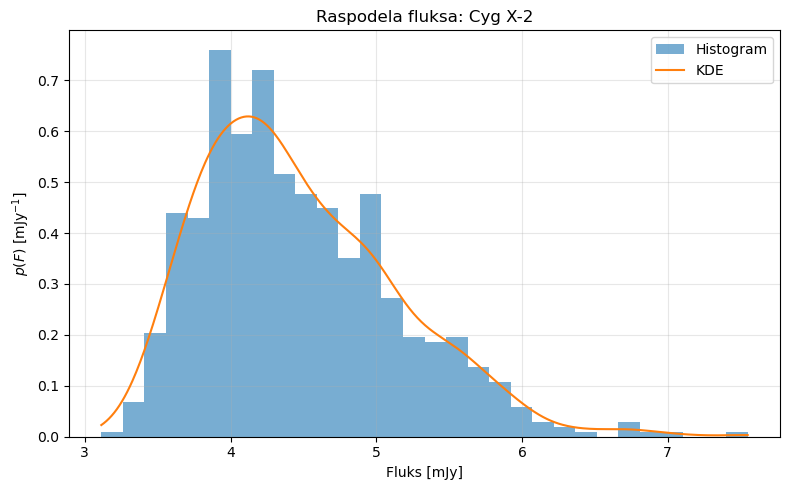

In [10]:
# ============================================================
#  HISTOGRAMI RASPODELE FLUKSA
# ============================================================

def nacrtaj_histogram(fluks, ime_objekta):
    plt.figure(figsize=(8,5))

    # histogram
    plt.hist(fluks, bins=30, density=True, alpha=0.6, label="Histogram")

    # KDE (glatka kriva)
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(fluks)
    x = np.linspace(min(fluks), max(fluks), 500)
    kde_vrednosti = kde(x)
    plt.plot(x, kde_vrednosti, label="KDE")

    plt.xlabel("Fluks [mJy]")
    plt.ylabel(r"$p(F)$ [$\mathrm{mJy}^{-1}$]")
    plt.title(f"Raspodela fluksa: {ime_objekta}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return {
        "sistem": ime_objekta,
        "fluks": fluks,
        "x_kde": x,
        "kde": kde_vrednosti
    }


# Sco
hist_sco = nacrtaj_histogram(fluks_sco_cist2, "Sco X-1")

# Her
hist_her = nacrtaj_histogram(fluks_her_cist2, "Her X-1")

# Cyg
hist_cyg = nacrtaj_histogram(fluks_cyg_cist2, "Cyg X-2")


### Komentar rezultata

Histogrami raspodele fluksa pokazuju da se sistemi razlikuju ne samo po intenzitetu varijabilnosti, već i po strukturi svojih stanja.

Sco X-1 ima široku raspodelu sa dva izražena maksimuma. To ukazuje na postojanje više dominantnih režima fluksa i na prelaze između različitih stanja sistema. Ovakav oblik je u skladu sa složenom i promenljivom dinamikom akrecionog diska.

Her X-1 pokazuje dominantan maksimum pri većim vrednostima fluksa, uz dodatne strukture pri nižim vrednostima. To ukazuje na glavni režim emisije, ali i na dodatne komponente varijabilnosti. Zbog velikog nagiba sistema, geometrijski efekti i zasenčenja mogu značajno doprineti obliku raspodele.

Cyg X-2 ima užu i približno jednovrhovnu raspodelu sa repom ka većim vrednostima fluksa. To ukazuje na stabilniji režim emisije, uz povremena odstupanja ka višim vrednostima.

## Lomb-Scargle analiza periodičnosti

Za analizu nepravilno uzorkovanih vremenskih serija korišćen je Lomb--Scargle periodogram.

Ova metoda omogućava detekciju dominantnih vremenskih skala bez potrebe za uniformnim uzorkovanjem podataka.

Spektralna snaga signala definiše se kao funkcija frekvencije:

$$
P(\omega)
$$

Maksimumi periodograma ukazuju na moguće periodične ili kvaziperiodične komponente u svetlosnoj krivi.


**** Lomb - Scargle ****


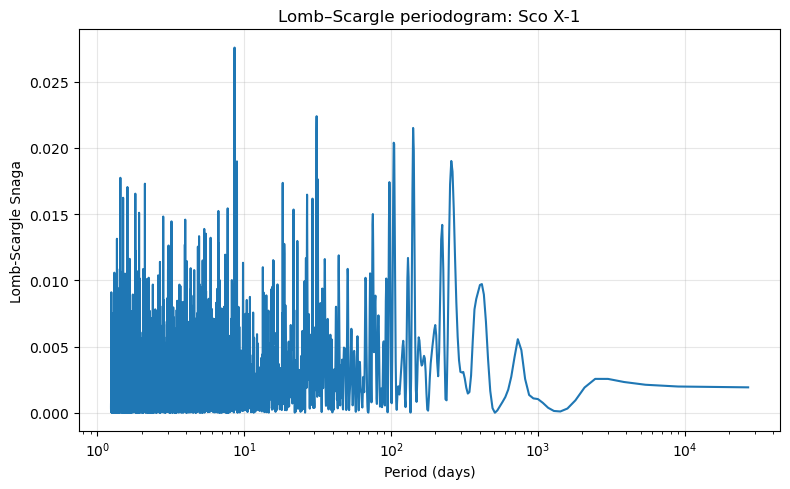


Sco X-1
Dominantni period: 8.581861969098085


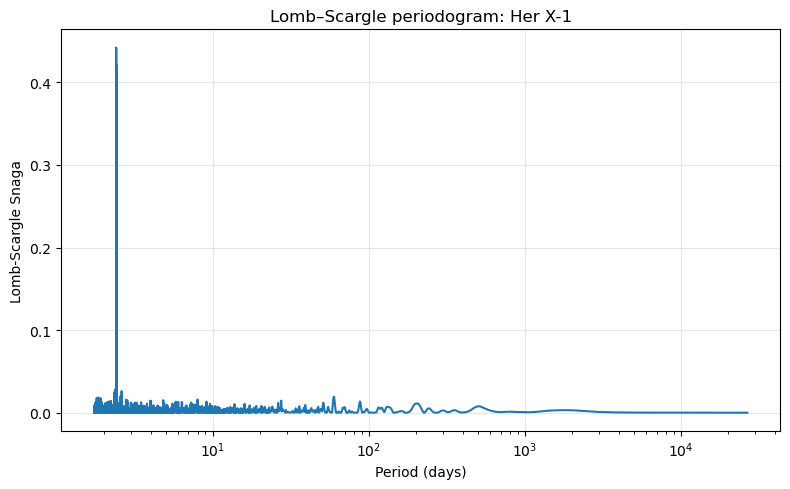


Her X-1
Dominantni period: 2.412343679246899


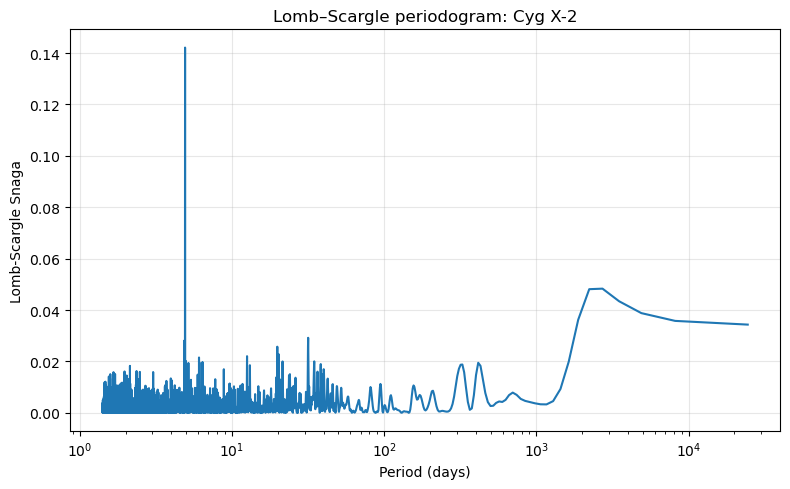


Cyg X-2
Dominantni period: 4.921895907172903


In [12]:
# ============================================================
#  LOMB–SCARGLE PERIODOGRAM
# ============================================================

from astropy.timeseries import LombScargle
print("\n**** Lomb - Scargle ****")
def nacrtaj_periodogram(vreme, fluks, ime_objekta):
    # frekvencije
    frekvencija, snaga = LombScargle(vreme, fluks).autopower()

    # pretvaranje u period
    period = 1 / frekvencija

    plt.figure(figsize=(8,5))
    plt.plot(period, snaga)

    plt.xlabel("Period (days)")
    plt.ylabel("Lomb-Scargle Snaga")
    plt.title(f"Lomb–Scargle periodogram: {ime_objekta}")

    plt.xscale("log")  # bolje se vide različite skale
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # dominantni period
    indeks_max = np.argmax(snaga)
    print(f"\n{ime_objekta}")
    print("Dominantni period:", period[indeks_max])

    return {
        "sistem": ime_objekta,
        "frekvencija": frekvencija,
        "period": period,
        "snaga": snaga,
        "dominantni_period": period[indeks_max]
    }


# Sco
period_sco = nacrtaj_periodogram(vreme_sco_cisto2, fluks_sco_cist2, "Sco X-1")

# Her
period_her = nacrtaj_periodogram(vreme_her_cisto2, fluks_her_cist2, "Her X-1")

# Cyg
period_cyg = nacrtaj_periodogram(vreme_cyg_cisto2, fluks_cyg_cist2, "Cyg X-2")


### Komentar rezultata

Dobijeni Lomb--Scargle periodogrami pokazuju značajne razlike u vremenskoj organizaciji varijabilnosti između analiziranih sistema.

Kod sistema Sco X-1 ne uočava se jasno dominantan i usamljen pik periodograma. Detektovani dominantni period iznosi približno $P \approx 8.58$ dana, dok poznati orbitalni period sistema iznosi $P_{\mathrm{orb}} \approx 0.787$ dana. Veliko odstupanje ukazuje da dobijeni period verovatno ne predstavlja stvarnu fizičku vremensku skalu sistema. Ovakav rezultat može biti posledica aliasinga, nepravilnog uzorkovanja podataka ili prisustva dugoročnih trendova u svetlosnoj krivi.

Kod sistema Her X-1 dominantni period iznosi približno $P \approx 2.41$ dana, što je relativno blisko poznatom orbitalnom periodu od $P_{\mathrm{orb}} \approx 1.7$ dana. Jasno izražen dominantni pik ukazuje na prisustvo stabilne periodične komponente u sistemu.

Za Cyg X-2 dobijen je dominantni period od približno $P \approx 4.92$ dana, što je približno polovina poznatog orbitalnog perioda sistema $(P_{\mathrm{orb}} \approx 9.8$ dana). Ovakav rezultat ukazuje na prisustvo harmonijske strukture u signalu i kombinaciju periodičnih i nepravilnih promena fluksa.

Dobijeni rezultati pokazuju da Sco X-1 karakterišu složene promene bez jasno definisanog dominantnog perioda, Her X-1 dominantno periodično ponašanje, dok Cyg X-2 predstavlja prelazni slučaj između organizovane i stohastičke varijabilnosti.

## Autokorelaciona analiza

Za analizu vremenske memorije sistema korišćena je diskretna korelaciona funkcija (DCF), pogodna za neravnomerno uzorkovane astronomske podatke.

Za svaki par merenja računata je vrednost:

$$
\mathrm{UDCF}_{ij} =
\frac{
(F_i - \langle F \rangle)
(F_j - \langle F \rangle)
}{
\sigma_F^2
}
$$

gde je:
- $F_i$ spektralni fotometrijski fluks [mJy],
- $\langle F \rangle$ srednja vrednost fluksa [mJy],
- $\sigma_F$ standardna devijacija fluksa [mJy].

Vremenski pomak definisan je kao:

$$
\Delta t_{ij} = t_j - t_i
$$

UDCF vrednosti grupisane su u binove širine 1 day, nakon čega je DCF računata kao srednja vrednost svih UDCF vrednosti unutar odgovarajućeg vremenskog intervala:

$$
\mathrm{DCF}(\tau) =
\frac{1}{M}
\sum \mathrm{UDCF}_{ij}
$$

DCF uzima vrednosti od -1 do 1, pri čemu pozitivne vrednosti označavaju korelaciju, a negativne antikorelaciju signala.

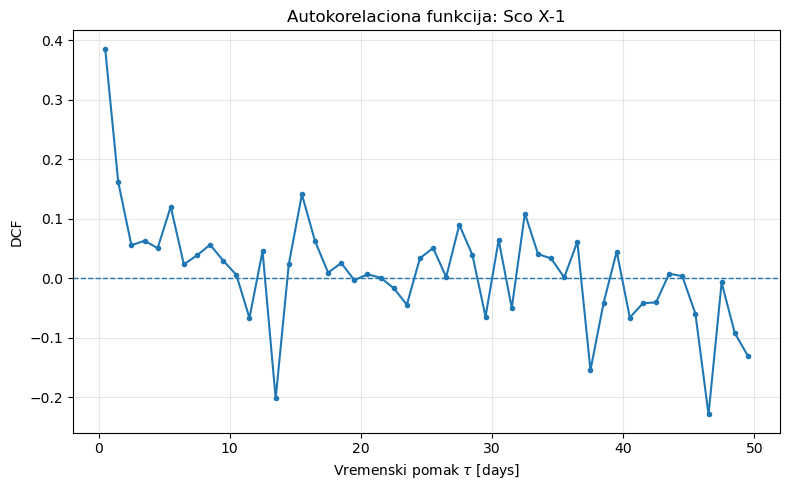

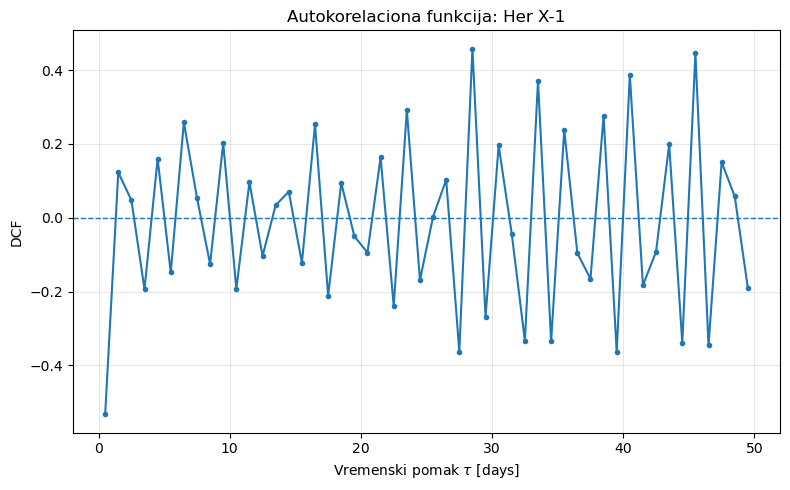

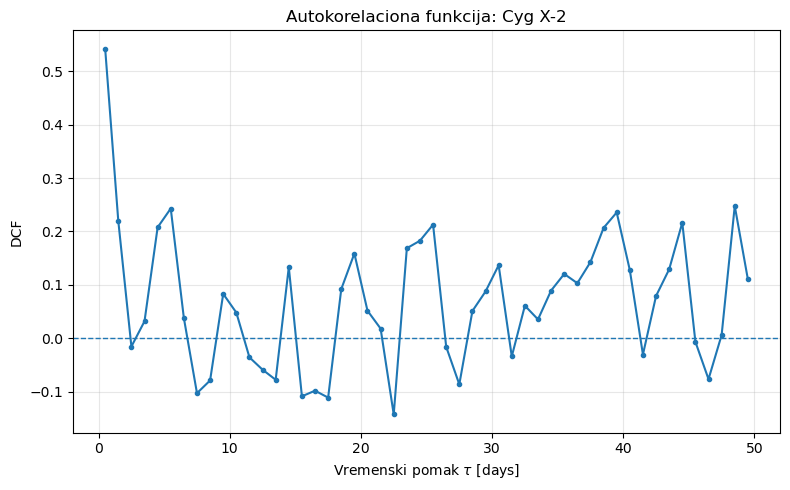

In [14]:
# ============================================================
#  AUTOKORELACIONA FUNKCIJA (DCF – binovana ACF)
# ============================================================

def dcf(vreme, fluks, max_lag=50, bin_width=1.0):
    # sortiranje
    idx = np.argsort(vreme)
    t = np.array(vreme)[idx]
    f = np.array(fluks)[idx]

    f_mean = np.mean(f)
    f_std = np.std(f)

    lags = []
    udcf = []

    # sve parove
    for i in range(len(t)):
        for j in range(i+1, len(t)):
            dt = t[j] - t[i]
            if dt > max_lag:
                break
            val = ((f[i]-f_mean)*(f[j]-f_mean)) / (f_std**2)
            lags.append(dt)
            udcf.append(val)

    lags = np.array(lags)
    udcf = np.array(udcf)

    # binovanje po lag-u
    bins = np.arange(0, max_lag+bin_width, bin_width)
    bin_centers = 0.5*(bins[:-1] + bins[1:])
    dcf_vals = []

    for k in range(len(bins)-1):
        mask = (lags >= bins[k]) & (lags < bins[k+1])
        if np.any(mask):
            dcf_vals.append(np.mean(udcf[mask]))
        else:
            dcf_vals.append(np.nan)

    return bin_centers, np.array(dcf_vals)


def nacrtaj_acf(vreme, fluks, ime):
    lag, acf = dcf(vreme, fluks, max_lag=50, bin_width=1.0)

    plt.figure(figsize=(8,5))
    plt.plot(lag, acf, marker='o', ms=3)
    plt.axhline(0, linestyle='--', linewidth=1)
    plt.xlabel(r"Vremenski pomak $\tau$ [days]")
    plt.ylabel("DCF")
    plt.title(f"Autokorelaciona funkcija: {ime}")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return {
        "sistem": ime,
        "lag": lag,
        "acf": acf
    }


# pozivi
acf_sco = nacrtaj_acf(vreme_sco_cisto2, fluks_sco_cist2, "Sco X-1")
acf_her = nacrtaj_acf(vreme_her_cisto2, fluks_her_cist2, "Her X-1")
acf_cyg = nacrtaj_acf(vreme_cyg_cisto2, fluks_cyg_cist2, "Cyg X-2")


### Komentar rezultata

Autokorelacione funkcije pokazuju različitu vremensku povezanost signala kod analiziranih sistema.

Kod Sco X-1 autokorelacija brzo opada sa porastom vremenskog pomaka i nema izražene pravilne sekundarne maksimume. To ukazuje na kratku vremensku memoriju sistema i na promene koje brzo gube vezu sa prethodnim stanjem signala.

Her X-1 pokazuje izražene oscilacije u autokorelacionoj funkciji. To potvrđuje prisustvo stabilne vremenske strukture i periodičnog ili kvaziperiodičnog ponašanja.

Cyg X-2 pokazuje umerenije opadanje autokorelacije, uz slabije i nepravilnije maksimume na većim vremenskim pomacima. To ukazuje na delimičnu vremensku strukturu, ali bez jasno dominantne periodičnosti kao kod Her X-1.

## Analiza mikrovarijabilnosti

Mikrovarijabilnost analizirana je pomoću brzine promene fluksa:

$$
\frac{\Delta F}{\Delta t}
=
\frac{
F_{i+1}-F_i
}{
t_{i+1}-t_i
}
$$

Ova veličina opisuje koliko brzo sistem menja svoj fluks između uzastopnih merenja.

Analiza mikrovarijabilnosti omogućava ispitivanje:
- kratkotrajnih fluktuacija,
- dinamike akrecionih procesa,
- i intenziteta brzih promena.


**** Mikrovarijabilnost ****

Sco X-1
Srednja ΔF/Δt: -0.241
Std ΔF/Δt: 8.665
Max |ΔF/Δt|: 30.528
Broj tačaka: 818


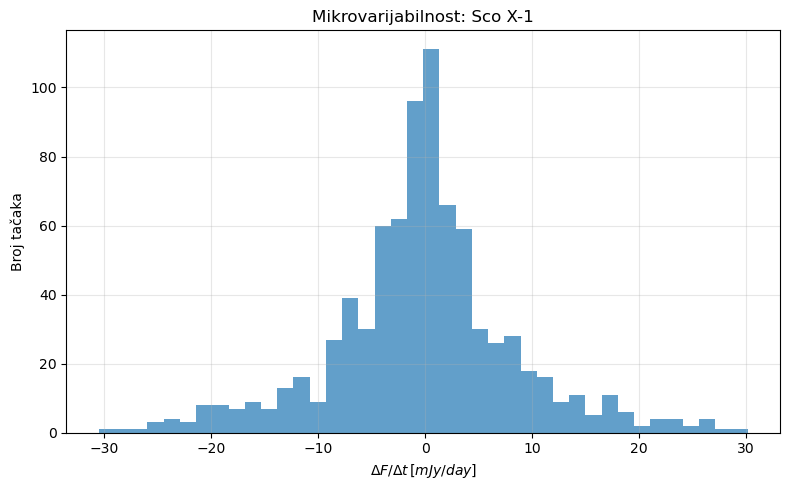


Her X-1
Srednja ΔF/Δt: 0.123
Std ΔF/Δt: 5.911
Max |ΔF/Δt|: 18.017
Broj tačaka: 593


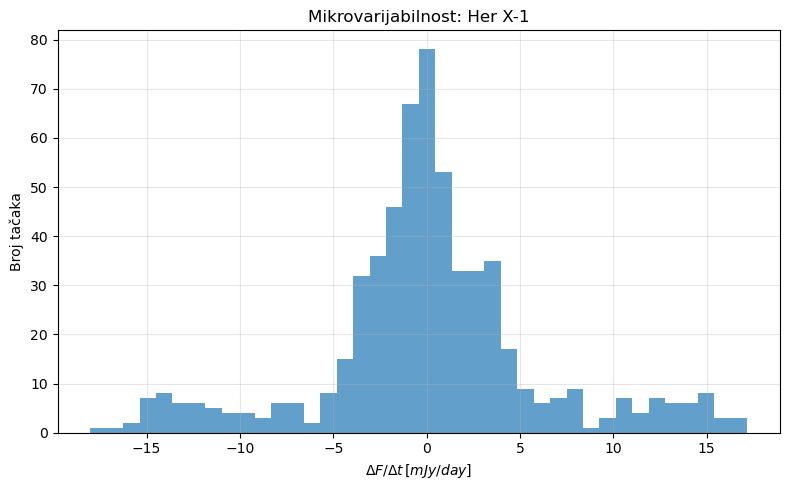


Cyg X-2
Srednja ΔF/Δt: 0.019
Std ΔF/Δt: 0.517
Max |ΔF/Δt|: 1.754
Broj tačaka: 669


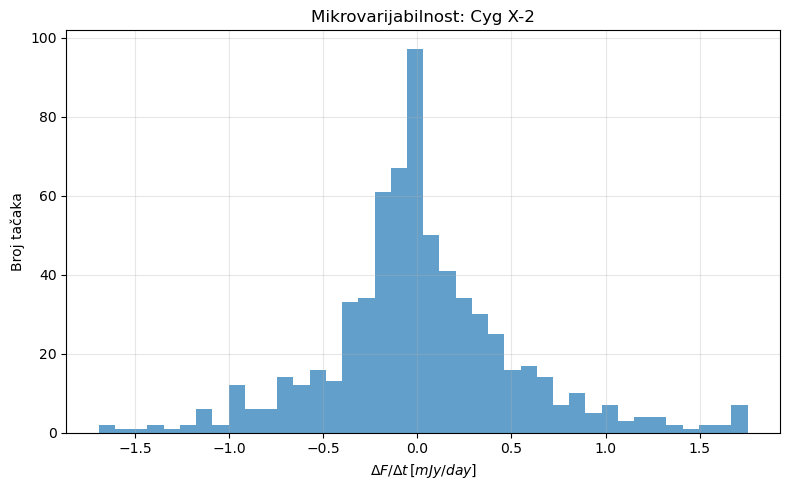

In [15]:
# ============================================================
#  MIKROVARIJABILNOST 
# ============================================================
print("\n**** Mikrovarijabilnost ****")
def mikrovarijabilnost(vreme, fluks, ime_objekta):
    vreme = np.array(vreme)
    fluks = np.array(fluks)

    # sortiranje po vremenu
    redosled = np.argsort(vreme)
    vreme = vreme[redosled]
    fluks = fluks[redosled]

    # razlike
    delta_vreme = np.diff(vreme)   # Δt
    delta_fluks = np.diff(fluks)   # ΔF

    # ======================================================
    # KLJUČNO: uklanjanje malih Δt 
    # ======================================================
    maska_dt = delta_vreme > 0.01   # ~15 minuta

    delta_vreme = delta_vreme[maska_dt]
    delta_fluks = delta_fluks[maska_dt]

    # brzina promene
    brzina_promene = delta_fluks / delta_vreme

    # ======================================================
    # uklanjanje NaN i inf vrednosti (dodatna sigurnost)
    # ======================================================
    maska_valid = np.isfinite(brzina_promene)
    brzina_promene = brzina_promene[maska_valid]

    # ======================================================
    # uklanjanje ekstremnih outliera (robusnije)
    # ======================================================
    med = np.median(brzina_promene)
    mad = np.median(np.abs(brzina_promene - med))
    sigma_rob = 1.4826 * mad

    maska_out = (brzina_promene > med - 5*sigma_rob) & (brzina_promene < med + 5*sigma_rob)
    brzina_promene = brzina_promene[maska_out]

    # ======================================================
    # statistika
    # ======================================================
    srednja = np.mean(brzina_promene)
    std = np.std(brzina_promene)
    max_abs = np.max(np.abs(brzina_promene))

    print(f"\n{ime_objekta}")
    print(f"Srednja ΔF/Δt: {srednja:.3f}")
    print(f"Std ΔF/Δt: {std:.3f}")
    print(f"Max |ΔF/Δt|: {max_abs:.3f}")
    print(f"Broj tačaka: {len(brzina_promene)}")

    # ======================================================
    # histogram
    # ======================================================
    plt.figure(figsize=(8,5))
    plt.hist(brzina_promene, bins=40, alpha=0.7)
    plt.xlabel(r"$\Delta F / \Delta t \, [mJy / day]$")
    plt.ylabel("Broj tačaka")
    plt.title(f"Mikrovarijabilnost: {ime_objekta}")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return {
        "sistem": ime_objekta,
        "brzina_promene": brzina_promene,
        "srednja": srednja,
        "std": std,
        "max_abs": max_abs
    }


# ============================================================
# POZIV
# ============================================================

mikro_sco = mikrovarijabilnost(vreme_sco_cisto2, fluks_sco_cist2, "Sco X-1")
mikro_her = mikrovarijabilnost(vreme_her_cisto2, fluks_her_cist2, "Her X-1")
mikro_cyg = mikrovarijabilnost(vreme_cyg_cisto2, fluks_cyg_cist2, "Cyg X-2")


### Komentar rezultata

Analiza mikrovarijabilnosti pokazuje koliko se brzo fluks menja između uzastopnih merenja.

Sve tri raspodele veličine $\Delta F / \Delta t$ centrirane su približno oko nule. To znači da nema izraženog sistematskog porasta ili opadanja fluksa tokom posmatranog perioda, već dominiraju promene u oba smera oko srednje vrednosti.

Sco X-1 ima najširu raspodelu i najveću standardnu devijaciju $\Delta F / \Delta t$, što pokazuje da ima najizraženije brze promene fluksa. Her X-1 takođe pokazuje značajnu mikrovarijabilnost, ali slabiju nego Sco X-1.

Cyg X-2 ima znatno užu raspodelu i najmanju standardnu devijaciju, što ukazuje na sporije i stabilnije kratkotrajne promene.

## Segmentacija svetlosnih krivih

Radi ispitivanja stabilnosti statističkih osobina tokom vremena, svetlosne krive podeljene su na više vremenskih segmenata.

Za svaki segment izračunate su:
- srednja vrednost fluksa,
- standardna devijacija,
- i osnovni parametri varijabilnosti.

Cilj segmentacije je provera:
- stacionarnosti sistema,
- dugoročnih promena,
- i stabilnosti režima emisije.


**** Segmentacija ****

Sco X-1 - Segment 1
Srednja vrednost: 33.668
Std: 8.400

Sco X-1 - Segment 2
Srednja vrednost: 33.191
Std: 8.322

Sco X-1 - Segment 3
Srednja vrednost: 32.574
Std: 8.603


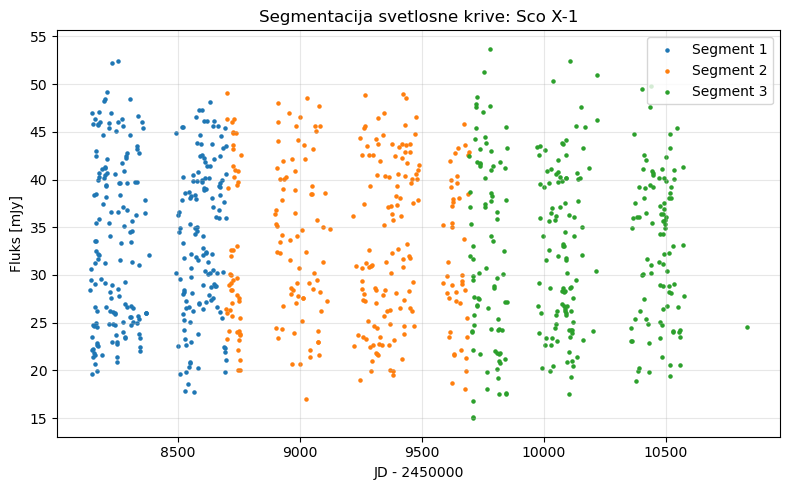


Her X-1 - Segment 1
Srednja vrednost: 16.006
Std: 5.510

Her X-1 - Segment 2
Srednja vrednost: 15.413
Std: 5.653

Her X-1 - Segment 3
Srednja vrednost: 15.637
Std: 5.596


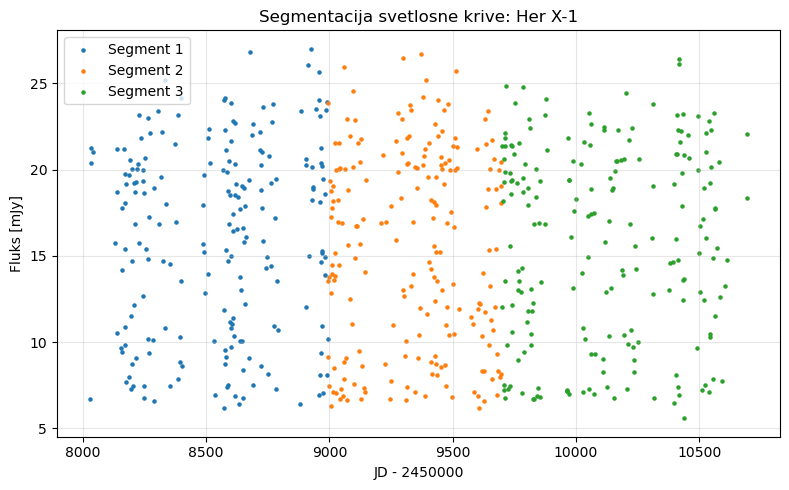


Cyg X-2 - Segment 1
Srednja vrednost: 4.557
Std: 0.665

Cyg X-2 - Segment 2
Srednja vrednost: 4.565
Std: 0.714

Cyg X-2 - Segment 3
Srednja vrednost: 4.292
Std: 0.603


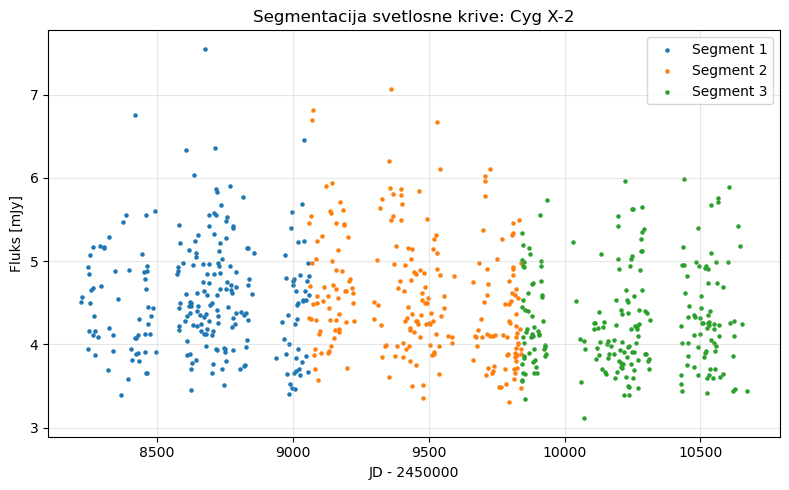

In [16]:
# ============================================================
#  DODATNA VREMENSKA ANALIZA (SEGMENTACIJA)
# ============================================================
print("\n**** Segmentacija ****")
def segmentacija(vreme, fluks, ime_objekta, broj_segmenata=3):
    vreme = np.array(vreme)
    fluks = np.array(fluks)

    # sortiranje
    redosled = np.argsort(vreme)
    vreme = vreme[redosled]
    fluks = fluks[redosled]

    # delimo na segmente
    segmenti = np.array_split(np.arange(len(vreme)), broj_segmenata)

    rezultati_segmenata = []
    
    jd0 = 2450000
    plt.figure(figsize=(8,5))

    for i, seg in enumerate(segmenti):
        plt.scatter(vreme[seg]-jd0, fluks[seg], s=5, label=f"Segment {i+1}")

        # osnovna statistika po segmentu
        srednja = np.mean(fluks[seg])
        std = np.std(fluks[seg])

        print(f"\n{ime_objekta} - Segment {i+1}")
        print(f"Srednja vrednost: {srednja:.3f}")
        print(f"Std: {std:.3f}")

        rezultati_segmenata.append({
            "segment": i + 1,
            "srednja": srednja,
            "std": std
        })
    plt.xlabel(f"JD - {jd0}")
    plt.ylabel("Fluks [mJy]")
    plt.title(f"Segmentacija svetlosne krive: {ime_objekta}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return {
        "sistem": ime_objekta,
        "segmenti": rezultati_segmenata
    }


# poziv
seg_sco = segmentacija(vreme_sco_cisto2, fluks_sco_cist2, "Sco X-1")
seg_her = segmentacija(vreme_her_cisto2, fluks_her_cist2, "Her X-1")
seg_cyg = segmentacija(vreme_cyg_cisto2, fluks_cyg_cist2, "Cyg X-2")


### Komentar rezultata

Segmentacija svetlosnih krivih pokazuje da su osnovne statističke osobine sistema relativno stabilne tokom posmatranog perioda.

Kod Sco X-1 srednja vrednost fluksa blago opada kroz segmente, ali standardna devijacija ostaje približno konstantna. To znači da se osnovni nivo emisije može blago menjati, dok intenzitet varijabilnosti ostaje stabilan.

Kod Her X-1 prisutne su manje promene srednje vrednosti, ali bez jasnog sistematskog trenda i bez značajne promene rasipanja podataka.

Kod Cyg X-2 i srednja vrednost i standardna devijacija ostaju najstabilnije, što je u skladu sa njegovim stabilnijim karakterom u odnosu na ostale sisteme.

Ovi rezultati opravdavaju korišćenje celokupnog skupa podataka u daljoj analizi, jer se osnovne karakteristike varijabilnosti ne menjaju značajno kroz vremenske segmente.

## Fizički smisleno poređenje sistema

Kako bi se dodatno interpretirala priroda varijabilnosti, definisani su odnosi između:
- ukupne varijabilnosti,
- amplitude promena,
- i brzine promena fluksa.

#### Odnos mikrovarijabilnosti

$$
R_{\mathrm{micro}}
=
\frac{
\sigma(\Delta F/\Delta t)
}{
F_{\mathrm{var}}
}
$$

#### Odnos amplitude i ukupne varijabilnosti

$$
R_{\mathrm{amp}}
=
\frac{
A
}{
F_{\mathrm{var}}
}
$$

Ovi odnosi omogućavaju procenu:
- da li sistem dominantno varira kroz brze fluktuacije,
- ili kroz sporije promene velikog raspona.

In [17]:
# ============================================================
#  FIZIČKI SMISLENO POREĐENJE SISTEMA
#     UPOREDNA ANALIZA OSNOVNIH PARAMETARA VARIJABILNOSTI
# ============================================================
print("\n**** Poređenje parametara ****")
tabela_uporedna = pd.DataFrame({
    "Sistem": ["Sco X-1", "Her X-1", "Cyg X-2"],

    "Fvar": [
        stat_sco["fvar"],
        stat_her["fvar"],
        stat_cyg["fvar"]
    ],

    "Relativna amplituda": [
        stat_sco["amplituda"] / stat_sco["srednja"],
        stat_her["amplituda"] / stat_her["srednja"],
        stat_cyg["amplituda"] / stat_cyg["srednja"]
    ],

    "Mikrovarijabilnost": [
        mikro_sco["std"],
        mikro_her["std"],
        mikro_cyg["std"]
    ]
})
for i, sistem in tabela_uporedna.iterrows():

    ime = sistem["Sistem"]

    fvar = sistem["Fvar"]
    amp = sistem["Relativna amplituda"]
    mikro = sistem["Mikrovarijabilnost"]

    odnos_brzine = mikro / fvar
    odnos_amplitude = amp / fvar

    print(f"\n{ime}")
    print(f"Odnos brzine i varijabilnosti (mikro/Fvar): {odnos_brzine:.3f}")
    print(f"Odnos amplitude i varijabilnosti (A/Fvar): {odnos_amplitude:.3f}")


**** Poređenje parametara ****

Sco X-1
Odnos brzine i varijabilnosti (mikro/Fvar): 33.974
Odnos amplitude i varijabilnosti (A/Fvar): 4.580

Her X-1
Odnos brzine i varijabilnosti (mikro/Fvar): 16.585
Odnos amplitude i varijabilnosti (A/Fvar): 3.827

Cyg X-2
Odnos brzine i varijabilnosti (mikro/Fvar): 3.439
Odnos amplitude i varijabilnosti (A/Fvar): 6.606


### Komentar rezultata 

Odnosi $R_{\mathrm{micro}}$ i $R_{\mathrm{amp}}$ ne predstavljaju nove nezavisne veličine, već povezuju rezultate osnovne statistike i mikrovarijabilnosti.

Sco X-1 ima najveću vrednost $R_{\mathrm{micro}}$, što znači da su brze promene fluksa veoma značajan deo njegove ukupne varijabilnosti. To je u skladu sa rezultatima mikrovarijabilnosti, gde Sco X-1 pokazuje najširu raspodelu $\Delta F / \Delta t$.

Her X-1 ima umerene vrednosti ovih odnosa, što ga postavlja u prelazni režim. Njegova varijabilnost nije određena samo brzim promenama, već i stabilnijom, periodičnijom strukturom.

Cyg X-2 ima najmanju vrednost $R_{\mathrm{micro}}$, što potvrđuje slab doprinos brzih fluktuacija. Međutim, njegova vrednost $R_{\mathrm{amp}}$ je najveća, što znači da promene većeg raspona imaju relativno veći značaj u odnosu na njegovu ukupnu varijabilnost.

Ova analiza pokazuje da se sistemi ne razlikuju samo po tome koliko variraju, već i po načinu na koji se ta varijabilnost ostvaruje.

## Kolmogorov-Smirnov test

Za kvantitativno poređenje raspodela fluksa korišćen je Kolmogorov-Smirnov test.

KS statistika definiše se kao maksimalno odstupanje između dve empirijske kumulativne raspodele:

$$
D
=
\max_x
|F_1(x)-F_2(x)|
$$

Pored KS statistike određuje se i p-vrednost, koja pokazuje verovatnoću da dva uzorka potiču iz iste raspodele.

In [18]:
# ============================================================
#  KS TEST 
# ============================================================
print("\n**** KS Test ****")
def relativni_fluks(fluks):
    return fluks / np.mean(fluks)

sco_rel = relativni_fluks(fluks_sco_cist2)
her_rel = relativni_fluks(fluks_her_cist2)
cyg_rel = relativni_fluks(fluks_cyg_cist2)



from scipy.stats import ks_2samp

def ks_test(a, b, ime1, ime2):
    stat, p = ks_2samp(a, b)

    print(f"\n{ime1} vs {ime2}")
    print(f"KS statistika: {stat:.4f}")
    print(f"p-vrednost: {p:.4e}")

ks_test(sco_rel, her_rel, "Sco X-1", "Her X-1")
ks_test(sco_rel, cyg_rel, "Sco X-1", "Cyg X-2")
ks_test(her_rel, cyg_rel, "Her X-1", "Cyg X-2")



**** KS Test ****

Sco X-1 vs Her X-1
KS statistika: 0.1770
p-vrednost: 2.4952e-10

Sco X-1 vs Cyg X-2
KS statistika: 0.2369
p-vrednost: 1.6575e-19

Her X-1 vs Cyg X-2
KS statistika: 0.3002
p-vrednost: 2.0768e-26


### Komentar rezultata

Kolmogorov--Smirnov test pokazuje da se raspodele fluksa svih parova sistema statistički značajno razlikuju.

Sve p-vrednosti su veoma male, što znači da je malo verovatno da posmatrani parovi sistema potiču iz iste raspodele fluksa.

Najmanje odstupanje dobijeno je između Sco X-1 i Her X-1, što ukazuje da su njihove raspodele međusobno sličnije nego u poređenjima sa Cyg X-2.

Veće odstupanje između Sco X-1 i Cyg X-2 potvrđuje da Cyg X-2 ima drugačiji i stabilniji režim promena fluksa.

Najveća razlika dobijena je između Her X-1 i Cyg X-2, što pokazuje da ova dva sistema imaju najslabiju međusobnu sličnost u raspodeli fluksa.

## Kullback--Leibler divergencija raspodela

Za kvantifikovanje razlika između raspodela fluksa korišćena je Kullback--Leibler (KL) divergencija, koja predstavlja informacionu meru razlike između dve raspodele verovatnoće.

Za dve diskretne raspodele P i Q, KL divergencija definisana je kao:

$
D_{\mathrm{KL}}(P||Q) =
\sum_i
P_i
\log
\left(
\frac{P_i}{Q_i}
\right)
$

gde su:
- $P_i ~i~ Q_i$ verovatnoće u i-tom binu histograma,
- $D_{\mathrm{KL}}$ informaciona razlika između raspodela.

Važi:

$
D_{\mathrm{KL}} = 0
$

za identične raspodele, dok veće vrednosti ukazuju na veće razlike između sistema.

KL divergencija nije simetrična:

$
D_{\mathrm{KL}}(P||Q)
\neq
D_{\mathrm{KL}}(Q||P)
$

Za procenu raspodela korišćeni su normalizovani histogrami relativnog fluksa sa zajedničkim opsegom binova za svaki par sistema.


**** KL Divergencija ****


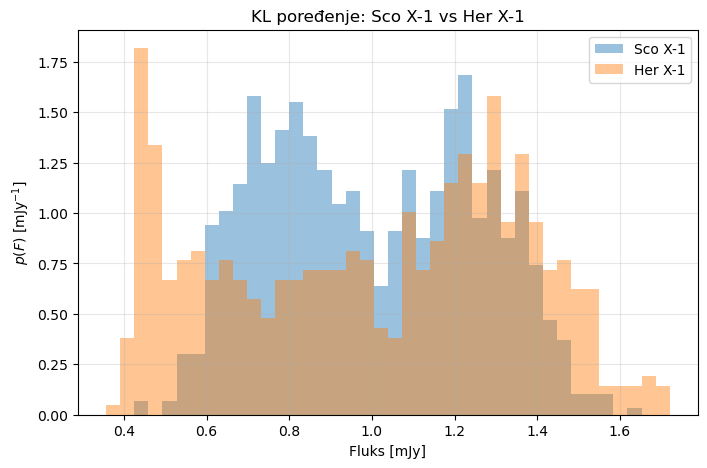


Sco X-1 vs Her X-1
D_KL(Sco X-1 || Her X-1) = 0.2934
D_KL(Her X-1 || Sco X-1) = 2.0790


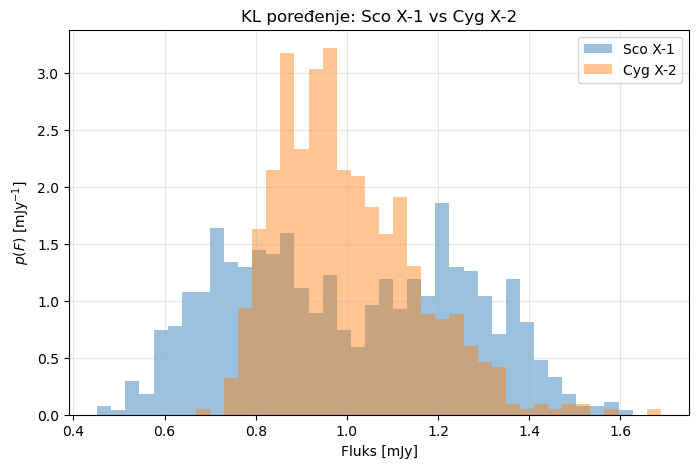


Sco X-1 vs Cyg X-2
D_KL(Sco X-1 || Cyg X-2) = 3.9336
D_KL(Cyg X-2 || Sco X-1) = 0.5255


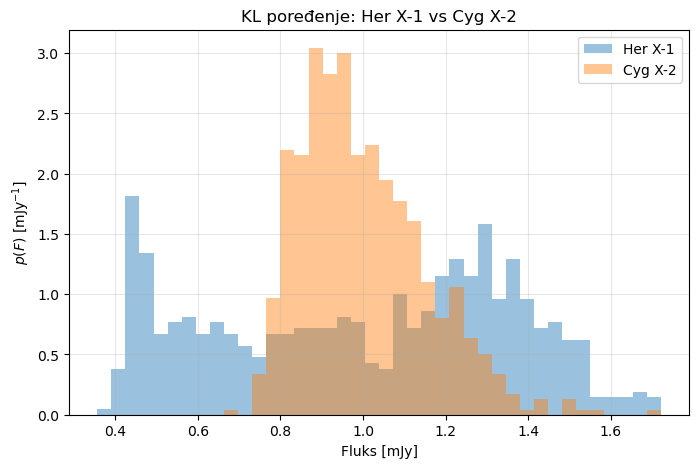


Her X-1 vs Cyg X-2
D_KL(Her X-1 || Cyg X-2) = 7.7244
D_KL(Cyg X-2 || Her X-1) = 0.8880


In [19]:
# ============================================================
#  KULLBACK-LEIBLER DIVERGENCIJA
#    POREĐENJE RASPODELA RELATIVNOG FLUKSA
# ============================================================

from scipy.stats import entropy

print("\n**** KL Divergencija ****")

def kl_divergencija(a, b, ime1, ime2, bins=40):
    # zajednički opseg da bi histogrami bili uporedivi
    xmin = min(np.min(a), np.min(b))
    xmax = max(np.max(a), np.max(b))

    # histogrami kao procena raspodele verovatnoće
    p, binovi = np.histogram(a, bins=bins, range=(xmin, xmax), density=False)
    q, _ = np.histogram(b, bins=binovi, density=False)

    

# ============================================================
# PLOT HISTOGRAMA
# ============================================================

    plt.figure(figsize=(8,5))

    plt.hist(a,
         bins=binovi,
         density=True,
         alpha=0.45,
         label=ime1,
         histtype="stepfilled")

    plt.hist(b,
         bins=binovi,
         density=True,
         alpha=0.45,
         label=ime2,
         histtype="stepfilled")

    plt.xlabel("Fluks [mJy]")
    plt.ylabel(r"$p(F)$ [$\mathrm{mJy}^{-1}$]")

    plt.title(f"KL poređenje: {ime1} vs {ime2}")

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()


# pretvaranje u verovatnoće
    p = p / np.sum(p)
    q = q / np.sum(q)

    # mala vrednost da se izbegne deljenje nulom i log(0)
    eps = 1e-12
    p = p + eps
    q = q + eps

    # ponovna normalizacija
    p = p / np.sum(p)
    q = q / np.sum(q)

    # KL divergencija
    dkl_pq = entropy(p, q)
    dkl_qp = entropy(q, p)
      
    print(f"\n{ime1} vs {ime2}")
    print(f"D_KL({ime1} || {ime2}) = {dkl_pq:.4f}")
    print(f"D_KL({ime2} || {ime1}) = {dkl_qp:.4f}")

    return {
        "poredjenje": f"{ime1} vs {ime2}",
        "D_KL_1_2": dkl_pq,
        "D_KL_2_1": dkl_qp
    }


kl_sco_her = kl_divergencija(sco_rel, her_rel, "Sco X-1", "Her X-1")
kl_sco_cyg = kl_divergencija(sco_rel, cyg_rel, "Sco X-1", "Cyg X-2")
kl_her_cyg = kl_divergencija(her_rel, cyg_rel, "Her X-1", "Cyg X-2")

### Komentar rezultata

Dobijeni rezultati pokazuju da analizirani sistemi imaju značajno različite raspodele fluksa i različite režime emisije.

Najmanja divergencija dobijena je između sistema Sco X-1 i Her X-1:

$
D_{\mathrm{KL}}(\mathrm{Sco}||\mathrm{Her}) = 0.2934
$

što ukazuje na relativnu sličnost njihovih raspodela. Veća obrnuta divergencija pokazuje da Her X-1 poseduje kompleksniju i izraženije strukturisanu raspodelu.

Za poređenje Sco X-1 i Cyg X-2 dobijena je znatno veća divergencija:

$
D_{\mathrm{KL}}(\mathrm{Sco}||\mathrm{Cyg}) = 3.9336
$

što pokazuje da Sco X-1 ima širu i kompleksniju raspodelu fluksa, dok Cyg X-2 ostaje koncentrisan oko stabilnijeg režima emisije.

Najveće odstupanje dobijeno je između sistema Her X-1 i Cyg X-2:

$
D_{\mathrm{KL}}(\mathrm{Her}||\mathrm{Cyg}) = 7.7244
$

što ukazuje na veoma različite režime emisije i vremensku organizaciju varijabilnosti.

Rezultati KL divergencije saglasni su sa histogramima raspodele fluksa, DCF analizom i osnovnom statistikom varijabilnosti: Sco X-1 i Her X-1 pokazuju kompleksnije i višerežimske raspodele, dok Cyg X-2 karakteriše stabilniji režim emisije.

### Zaključak prvog dela analize

Sprovedena analiza omogućila je višeslojnu karakterizaciju varijabilnosti sistema Sco X-1, Her X-1 i Cyg X-2.

Kombinacijom:
- osnovne statistike,
- raspodele fluksa,
- vremenske analize,
- mikrovarijabilnosti,
- i statističkog poređenja,

dobijena je fizički smisleno interpretirana slika promenljivosti sistema.

Rezultati pokazuju da se sistemi razlikuju ne samo po intenzitetu promena, već i po unutrašnjoj organizaciji varijabilnosti, dominantnim režimima emisije i vremenskoj strukturi signala.

Dobijeni rezultati predstavljaju stabilnu osnovu za nastavak projekta, koji može uključivati detaljnije povezivanje fotometrijskih i spektralnih osobina sistema radi fizičke interpretacije akrecionih procesa.